In [1]:
import src.augmentations.LightCurveTransform as LC

In [1]:
from src.layers.classifiers.Hierarchical import HierarchicalClassifier
from src.utils.data.AlerceDictionaries import ALERCE_TAXONOMY
from src.layers.transformer.lightcurve import LightCurveTransformer
import torch

TypeError: 'int' object is not iterable

In [2]:
import torch
import torch.nn as nn
from src.layers.classifiers.MixedClassifier import MixedClassifier
from src.layers.classifiers.TokenClassifier import TokenClassifier

class HierarchicalClassifier(nn.Module):
    def __init__(self, input_dim:int, hierarchy:dict, dropout=0.01,**kwargs):
        super().__init__()
        self.hierarchy = hierarchy
        self.num_node_classes = len(list(hierarchy.keys()))
        self.num_leaf_classes = [len(value) for key,value in hierarchy.items()]
        
        assert all([isinstance(i,int) for i in self.num_leaf_classes])
        assert self.num_node_classes == len(self.num_leaf_classes)
        
        self.node_classifier= TokenClassifier(input_dim,self.num_node_classes)
        self.leaf_classifiers = nn.ModuleList([TokenClassifier(input_dim,self.num_leaf_classes[i]) for i in range(len(self.num_leaf_classes))])
 
    
    def forward(self, x):
        node_pred = self.node_classifier(x) # should return an int in range num_node_classifiers
        node_pred = torch.argmax(node_pred,dim = 1).to(dtype=torch.int)
        leaf_pred = torch.zeros((x.size(0),sum(self.num_leaf_classes)),device = x.device,dtype = float)
        leaf_pred = torch.zeros(x.size(0))
        for i in range(self.num_node_classes):
            indices = torch.where(node_pred == i)
            partial_leaf_pred = self.leaf_classifiers[i](x[indices])
            partial_leaf_pred = torch.argmax(partial_leaf_pred, dim = -1)
            mapped = list(map(lambda x: list(self.hierarchy[str(i)].values())[x.item()],partial_leaf_pred))
            leaf_pred[indices] = torch.tensor(mapped, dtype = x.dtype)
        return  (node_pred, leaf_pred)


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class HierarchicalLoss(nn.Module):
    def __init__(self,taxonomy: dict,node_coeff:int = 0.5, leaf_coeff = 0.5):
        super().__init__()
        self.taxonomy = taxonomy
        self.node_classes = taxonomy.hierarchy_tree.keys()
        self.leaf_classes =  list(range(sum([len(taxonomy.hierarchy_tree[key]) for key in list(taxonomy.hierarchy_tree.keys())])))
        self.node_coeff= node_coeff
        self.lead_coeff = leaf_coeff
        print(taxonomy.values_as_keys())
        
        self.inv_taxonomy =  taxonomy.values_as_keys()
        print(self.inv_taxonomy)
    def forward(self,node_leaf_tuple:tuple,target):
        node_target = torch.tensor(list(map(lambda x: self.inv_taxonomy[str(x.item())].item(),target)))
        hierarchical_loss = 0
        hierarchical_loss += F.functional.cross_entropy(node_pred, node_target) * self.node_coeff
        hierarchical_loss += F.functional.cross_entropy(leaf_pred, target) * self.lead_coeff
        return hierarchical_loss

In [4]:
print(ALERCE_TAXONOMY.hierarchy_tree)
print(ALERCE_TAXONOMY[0])

{0: {'SNIa': 4, 'SNII': 9, 'SNIbc': 16, 'SLSN': 17, 'TDE': 18, 'SNIIb': 19, 'SNIIn': 20, 'Microlensing': 21}, 1: {'AGN': 0, 'QSO': 1, 'YSO': 3, 'CV/Nova': 5, 'Blazar': 8}, 2: {'EA': 2, 'RRLc': 6, 'RSCVn': 7, 'EB/EW': 10, 'LPV': 11, 'CEP': 12, 'RRLab': 13, 'Periodic-Other': 14, 'DSCT': 15}}
{0: {'SNIa': 4, 'SNII': 9, 'SNIbc': 16, 'SLSN': 17, 'TDE': 18, 'SNIIb': 19, 'SNIIn': 20, 'Microlensing': 21}, 1: {'AGN': 0, 'QSO': 1, 'YSO': 3, 'CV/Nova': 5, 'Blazar': 8}, 2: {'EA': 2, 'RRLc': 6, 'RSCVn': 7, 'EB/EW': 10, 'LPV': 11, 'CEP': 12, 'RRLab': 13, 'Periodic-Other': 14, 'DSCT': 15}}


TypeError: unhashable type: 'dict'

In [9]:
n = 100
input_dict = {'data': torch.randint(100,(n,200,2)).float(), 'time': torch.rand((n,200,2)), 'mask': torch.rand((n,200,2))> 0.5}
target = torch.randint(22,(n,))
config = {'num_heads':4,
'embedding_size_sub':128,
'embedding_size':128,
'num_encoders':3,
}


In [17]:
test_classifier = HierarchicalClassifier(128,ALERCE_TAXONOMY.hierarchy_tree)
model = LightCurveTransformer(**config)
loss = HierarchicalLoss(ALERCE_TAXONOMY)

model.eval()
test_classifier.eval()
out = model(**input_dict)
node_pred,leaf_pred = test_classifier(out)

loss((node_pred,leaf_pred),target)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


{4: 'SNIa', 9: 'SNII', 16: 'SNIbc', 17: 'SLSN', 18: 'TDE', 19: 'SNIIb', 20: 'SNIIn', 21: 'Microlensing', 0: 'AGN', 1: 'QSO', 3: 'YSO', 5: 'CV/Nova', 8: 'Blazar', 2: 'EA', 6: 'RRLc', 7: 'RSCVn', 10: 'EB/EW', 11: 'LPV', 12: 'CEP', 13: 'RRLab', 14: 'Periodic-Other', 15: 'DSCT'}
{4: 'SNIa', 9: 'SNII', 16: 'SNIbc', 17: 'SLSN', 18: 'TDE', 19: 'SNIIb', 20: 'SNIIn', 21: 'Microlensing', 0: 'AGN', 1: 'QSO', 3: 'YSO', 5: 'CV/Nova', 8: 'Blazar', 2: 'EA', 6: 'RRLc', 7: 'RSCVn', 10: 'EB/EW', 11: 'LPV', 12: 'CEP', 13: 'RRLab', 14: 'Periodic-Other', 15: 'DSCT'}


KeyError: '11'

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


<Axes: >

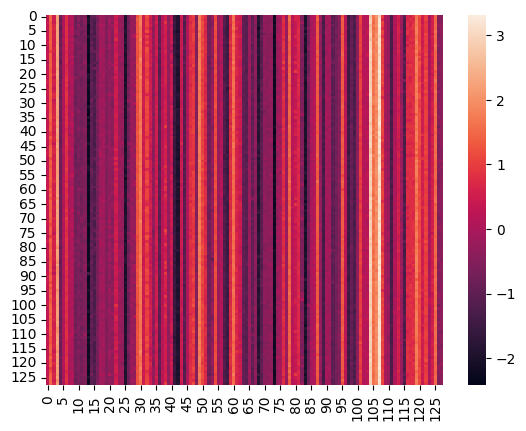

In [129]:
import torch
import torch.nn as nn
from src.layers.timeEncoders import TimeHandler 
from src.layers.tokenEmbeddings import Token


class SectionEmbeddingAttention(nn.MultiheadAttention):
    def __init__(self,d_model,
            nhead,
            dim_feedforward,
            activation="gelu",
            dropout=0.2,
            n_sections = 4,
            batch_first=True,
            norm_first=True,):
        super().__init__(embed_dim = d_model,num_heads=nhead)
        self.batch_first =True
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=1, batch_first=True)
        self.self_attn = self.attn
        self.FC = nn.Linear(n_sections*d_model,n_sections*d_model)

    
    def forward(self,query,key,value,
                key_padding_mask, need_weights=True, 
                attn_mask=None, 
                average_attn_weights=True,
                is_causal=False):
        attn_output, _ = self.attn(query, key, value, key_padding_mask = key_padding_mask)  # (bsz * embed_sec, seqlen, sec_n)
        # Reshape back to original form

        attn_output = attn_output.view(query.size(0)//4, 4, 401, 32)  # (bsz, embed_sec, seqlen, sec_n)
        # Permute back to original shape (bsz, seqlen, 32, 4)
        attn_output = attn_output.permute(0, 2, 3, 1)
        out = self.FC(attn_output.flatten(2))
        out = out.reshape(query.shape)

        return out
    
    
class LightCurveTransformer(nn.Module):
    def __init__(self, **kwargs):
        super(LightCurveTransformer, self).__init__()
        # TODO add assert

        self.time_encoder = TimeHandler(**kwargs)
        self.num_heads = kwargs["num_heads"]
        # trans = nn.TransformerEncoder(
        #    encoder_layer=encoder_layer,
        #    num_layers=kwargs["num_encoders"],
        #    norm=nn.LayerNorm(self.sequence_section),
        # )
        assert (
            kwargs["embedding_size"] % kwargs["num_heads"] == 0
        ), "embedding_size not div by numheads"
        self.embed_sec = kwargs["embedding_size"] // kwargs["num_heads"]
        self.sec_n = kwargs["num_heads"]
        self.learnable_tokens = nn.Parameter(
            torch.randn(1, 1, self.embed_sec, self.sec_n)
        )  # (1, 1, 32, 4)
        encoder_layer =  encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_sec,
            nhead=1,
            dim_feedforward=8*self.embed_sec,
            activation="gelu",
            dropout=0.05,
            batch_first=True,
            norm_first=True,
        )
        attn = SectionEmbeddingAttention(d_model=self.embed_sec,
            nhead=1,
            dim_feedforward=4*kwargs["embedding_size"]//kwargs['num_heads'],
            activation="gelu",
            dropout=0.2,
            batch_first=True,
            norm_first=True,)
        encoder_layer.self_attn = attn
        self.register_buffer("ones", torch.ones(1, 1, 1, dtype=bool))
        self.transformer_lc = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=3,
            # norm=nn.LayerNorm(self.embed_sec),
        )
        self.out_norm = nn.LayerNorm(kwargs["embedding_size"])

    def embedding_light_curve(self, x, t, mask=None, **kwargs):
        x_mod, m_mod, t_mod = self.time_encoder(**{"x": x, "t": t, "mask": mask})
        m_mod = torch.cat(
            [
                self.ones.expand(x.shape[0], 1, 1),
                m_mod,
            ],
            axis=1,
        )
        return x_mod, m_mod, t_mod

    def forward(self, data, time, mask, **kwargs):
        x_mod, m_mod, _ = self.embedding_light_curve(
            **{"x": data, "t": time, "mask": mask}
        )
        x_mod = x_mod.unsqueeze(-1).view(
            x_mod.size(0), x_mod.size(1), self.embed_sec, self.num_heads
        )
        tokens = self.learnable_tokens.expand(
            x_mod.size(0), -1, -1, -1
        )  # Expand to match batch size
        x_mod = torch.cat([tokens, x_mod], dim=1)  # (bsz, 401, 32, 4)
        
        x_mod = x_mod.permute(0, 3, 1, 2)  # (bsz, embed_sec, 401, sec_n)
        bsz, sec_n,seqlen, embed_sec  = x_mod.shape
        x_mod_reshaped = x_mod.reshape(bsz * sec_n, seqlen, embed_sec)
        output = self.transformer_lc(
            src=x_mod_reshaped,
            src_key_padding_mask=~(m_mod.squeeze(-1).repeat(self.sec_n, 1)),
        )  # (bsz * embed_sec, 401, sec_n)
        output = output.view(
            data.size(0), self.sec_n, x_mod.size(2), self.embed_sec
        )  # (bsz, embed_sec, 401, sec_n)
        output = output.permute(0, 2, 3, 1)

        return self.out_norm(output[:, 0, :, :].flatten(1))
n = 128
input_dict = {'data': torch.randint(0,100,(n,200,2)).float(), 'time': torch.rand((n,200,2)), 'mask': torch.rand((n,200,2))> 0.5}

config = {'num_heads':4,
'embedding_size_sub':128,
'embedding_size':128,
'num_encoders':3,
}
model = LightCurveTransformer(**config)
out = model(**input_dict)

import seaborn as sns

sns.heatmap(out.detach()[:,:].cpu().numpy())

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.Size([256, 401, 32, 4])


<Axes: >

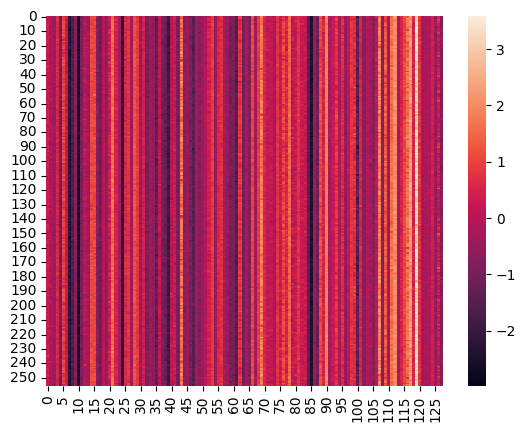

In [110]:


class SectionEmbeddingAttention(nn.TransformerEncoderLayer):
    def __init__(self,**kwargs):
        encoder = {'d_model': kwargs['embedding_size'],
                   'nhead': kwargs['num_heads']}
        super().__init__(**encoder)
        self.len_ = kwargs['embedding_size']// kwargs['num_heads']
        self.batch_first =True
        self.attn = nn.MultiheadAttention(embed_dim=self.len_, num_heads=1, batch_first=True)
        self.self_attn = self.attn
        self.FC = nn.Linear(kwargs['embedding_size'],kwargs['embedding_size'])
        
    def forward(self,query,key,value,
                key_padding_mask, need_weights=True, 
                attn_mask=None, 
                average_attn_weights=True,
                is_causal=False):

        attn_output, _ = self.attn(query, key, value, key_padding_mask = key_padding_mask)  # (bsz * embed_sec, seqlen, sec_n)
        # Reshape back to original form
        attn_output = attn_output.view(query.size(0)//4, 4, 401, 32)  # (bsz, embed_sec, seqlen, sec_n)
        # Permute back to original shape (bsz, seqlen, 32, 4)
        attn_output = attn_output.permute(0, 2, 3, 1)
        return out

class LightCurveTransformer(nn.Module):
    def __init__(self, **kwargs):
        super(LightCurveTransformer, self).__init__()
        # TODO add assert
        assert kwargs["embedding_size"] % kwargs["num_heads"] == 0
        self.sequence_section = int(kwargs["embedding_size"] / kwargs["num_heads"])
        self.time_encoder = TimeHandler(**kwargs)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.sequence_section,
            nhead=1,
            dim_feedforward=8*self.sequence_section,
            activation="gelu",
            dropout=0.05,
            batch_first=True,
            norm_first=True,
        )
        encoder_layer.self_attn = SectionEmbeddingAttention(**kwargs)
        self.num_heads = kwargs["num_heads"]
        trans = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=3,
            # norm=nn.LayerNorm(self.sequence_section),
        )
        self.encoder_list = nn.ModuleList([trans for _ in range(self.num_heads)])
        self.tokens = nn.ModuleList(
            [Token(self.sequence_section) for _ in range(self.num_heads)]
        )
        
        self.out_norm = nn.LayerNorm(kwargs["embedding_size"])
        self.register_buffer("ones", torch.ones(1, 1, 1, dtype=bool))
        self.out_FC = nn.Linear(kwargs['embedding_size'],kwargs['embedding_size'])
    def split(self, x_mod):
        x_mod = x_mod.unsqueeze(-1).reshape(
            x_mod.size(0), x_mod.size(1), self.sequence_section, self.num_heads
        )
        return x_mod

    def embedding_light_curve(self, x, t, mask=None, **kwargs):
        x_mod, m_mod, t_mod = self.time_encoder(**{"x": x, "t": t, "mask": mask})
        m_mod = torch.cat(
            [
                self.ones.expand(x.shape[0], 1, 1),
                m_mod,
            ],
            axis=1,
        )
        return x_mod, m_mod, t_mod

    def add_token(self, x_mod, i):
        return torch.cat([self.tokens[i](x_mod.shape[0]), x_mod], axis=1)

    def forward(self, data, time, mask, **kwargs):
        x_mod, m_mod, _ = self.embedding_light_curve(
            **{"x": data, "t": time, "mask": mask}
        )
        tokens = []
        x_mod = x_mod.unsqueeze(-1).reshape(
            x_mod.size(0), x_mod.size(1), self.sequence_section, self.num_heads
        )
        for i in range(self.num_heads):
            in_ = self.add_token(x_mod[:, :, :, i], i)
            tokens.append(
                self.encoder_list[i](
                    src=in_, src_key_padding_mask=~(m_mod.squeeze(-1))
                )[:, 0, :]
            )
        out = torch.concat(tokens, axis=-1)
        return self.out_norm(self.out_FC(out))

    
n = 256
input_dict = {'data': torch.randint(0,100,(n,200,2)).float(), 'time': torch.rand((n,200,2)), 'mask': torch.rand((n,200,2))> 0.5}

config = {'num_heads':4,
'embedding_size_sub':128,
'embedding_size':128,
'num_encoders':3,
}
model = LightCurveTransformerALL(**config)
out = model(**input_dict)

import seaborn as sns

sns.heatmap(out.detach()[:,:].cpu().numpy())

In [31]:
out = model(**input_dict)

torch.Size([100, 400, 128])


RuntimeError: shape '[128, 400, 32, 4]' is invalid for input of size 5120000

AttributeError: 'tuple' object has no attribute 'shape'

In [1]:



class LightCurveTransformerSEP(nn.Module):
    def __init__(self, **kwargs):
        super(LightCurveTransformerSEP, self).__init__() 
        self.time_encoder = TimeHandler(**kwargs)
        self.memory = Token(**kwargs)
        self.encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(d_model = kwargs['embedding_size'],
                                                 nhead=kwargs['num_heads'],
                                                 dim_feedforward=kwargs['embedding_size_sub'],
                                                 activation = 'gelu',
                                                 dropout=0.00,
                                                 batch_first=True,
                                                 norm_first=True,)
                                                 ,num_layers=kwargs['num_encoders'], 
                                                 norm = nn.LayerNorm(kwargs['embedding_size']))
        input_ = kwargs['embedding_size']
        hidden_ = kwargs['embedding_size']
        output_ = 400
        self.decoder = nn.TransformerDecoder(nn.TransformerDecoderLayer(d_model = input_,
                                                nhead=kwargs['num_heads'],
                                                 dim_feedforward=kwargs['embedding_size_sub'],
                                                 activation = 'gelu',
                                                 dropout=0.00,
                                                 batch_first=True,)
                                             ,num_layers=kwargs['num_encoders'], )
        
        self.embedding_size = kwargs['embedding_size']
        self.linear_proj = nn.Linear(input_,2)
    def embedding_light_curve(self, x, t, mask=None, **kwargs):
        x_mod, m_mod, t_mod = self.time_encoder(**{"x": x, "t": t, "mask": mask})
        x_mod = torch.cat([self.memory(x.shape[0]), x_mod], axis=1)
        m_mod =  torch.cat([torch.ones(1, 1, 1,device=x.device).bool().repeat(x.shape[0],1,1), m_mod], axis=1)
        return x_mod, m_mod , t_mod
    
    def forward(self, data, time, mask, **kwargs):
        x_mod, m_mod, _ = self.embedding_light_curve(**{"x": data, "t": time, "mask": mask}) 
        m_mod =  ~(m_mod.squeeze(-1))
        
        x_emb = self.encoder(**{"src": x_mod, "src_key_padding_mask":m_mod})[:,1:,:] # m_mod.squeeze(-1)
        
        #x_emb = x_emb / x_emb.norm(dim = 1,keepdim = True)
        #memory = self.tofourh(x_emb[:,0,:])
        #res = self.linear_proj(x_emb)
        #print(res.shape)
        
       # memory = self.tofourh(memory)  
        #print(data.shape,(data,x_emb.reshape(data.size(0),200,self.embedding_size*2)).shape)
        decoded = self.decoder(data.flatten(1).unsqueeze(-1).repeat(1,1,128),x_emb)
        #print(time.shape,decoded.shape)
        #
        # print(decoded.shape)
        return data.flatten(1).unsqueeze(-1).repeat(1,1,128),decoded
        
    
    

In [2]:
model = LightCurveTransformerSEP(**{'num_heads':4,
                                     
                               'embedding_size_sub':512,
                               'embedding_size':128,
                               'num_encoders':3,
                            })
input_dict = {'data': torch.rand((10,200,2)), 'time': torch.rand((10,200,2)), 'mask': torch.rand((10,200,2))> 0.5}

 

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
from torch.utils.data import  DataLoader
from src.data.handlers import SSLDataset

from src.data.modules.LitData  import LitData
from src.data.modules.LitPretrain import LitPretrain

module = LitPretrain(**{'data_root': '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12',
   'use_sampler': False,
   'batch_size': 256})

train_dataloader = module.train_dataloader()
val_dataloader = module.val_dataloader()


True
full dataset size: 286178
NOT USING SAMPLER FOR DATASET train
NOT USING SAMPLER FOR DATASET validation


In [43]:
maxes = []
for batch in train_dataloader:
    b1 = batch
        
    max = b1['time'].flatten().numpy().max()
    maxes.append(max.item())


#print(b1['time'].mean(dim =dim),b1['time'].std(dim = dim))



In [44]:
import numpy as np
print(np.array(maxes).max())

2464.10791015625


In [4]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from tqdm import tqdm
from src.losses.VICReg import VICReg
your_model = model
# Define loss function

# Training loop
num_epochs = 2  # Change as needed
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
optimizer = AdamW(your_model.parameters(), lr= 1e-3)
your_model.to(device)
criterion = nn.MSELoss()
for epoch in range(num_epochs):
    # Training phase
    batch_count = 0
    your_model.train()
    train_loss = 0.0
    for batch in train_dataloader:
        optimizer.zero_grad()
        
        batch_data = batch
        batch_data  = {key:value.to(device) for key,value in batch_data.items()}
       # aug_batch_data  = {key:value.to(device) for key,value in aug_batch_data.items()}
        data,decoded = your_model(**batch_data)
        #aug_x_emb = your_model(**aug_batch_data)
         
        loss = torch.sqrt(criterion(decoded,data))
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        print(f'-- Batch count: {batch_count}/ {len(train_dataloader)} || Step Loss: {loss:.4f}', end = '\r') # || cov {loss_dict["not_weighted_cov"]:.4f} || var {loss_dict["not_weighted_1menos_var"]:.4f} || inv {loss_dict["not_weighted_inv"]:.4f}', end = '\r')
        batch_count +=1
    train_loss /= len(train_dataloader)  # Average loss over batches
    
    # Validation phase
    your_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch_data = batch
            batch_data  = {key:value.to(device) for key,value in batch_data.items()}
            #aug_batch_data  = {key:value.to(device) for key,value in aug_batch_data.items()}
            data,decoded = your_model(**batch_data)
            loss = torch.sqrt(criterion(decoded,data))

            
            val_loss += loss.item()
    
    val_loss /= len(val_dataloader)  # Average loss over batches
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


KeyboardInterrupt: 

In [ ]:
asdfadsf

In [82]:
seed = 0
from src.data.modules.LitData  import LitData
args = {'general':{}}
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 512
pl_datal = LitData(**args['general'])
dataloader = pl_datal.val_dataloader() 

using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


In [83]:
target = None
preds_out = None
import numpy as np
model.eval().to(device = 'cuda:2')  
count = 0

for b1 in tqdm(dataloader):
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    t = b1['labels']
    #print(b1.keys())
    x_emb,t_emb = your_model(**b1)
    x_emb = x_emb[:,0,:]
    t_emb = t_emb[:,0,:]
    preds_out = (
        np.concatenate([preds_out, x_emb.detach().cpu().numpy()])
        if preds_out is not None
        else x_emb.cpu().detach().numpy()
    ) 
    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.detach().cpu().numpy()
    )
    if count > 2000:
        break
    count +=1

100%|██████████| 80/80 [00:12<00:00,  6.49it/s]


In [84]:
MIN_DIST = 0.1
METRIC = 'euclidean'
N_NEI = 30

In [85]:
import umap
umap_model = umap.UMAP(n_components=2, metric = METRIC, min_dist = MIN_DIST,n_neighbors = N_NEI)
umap_result = umap_model.fit_transform(preds_out)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [86]:
umap_result = umap_result / umap_result.max()

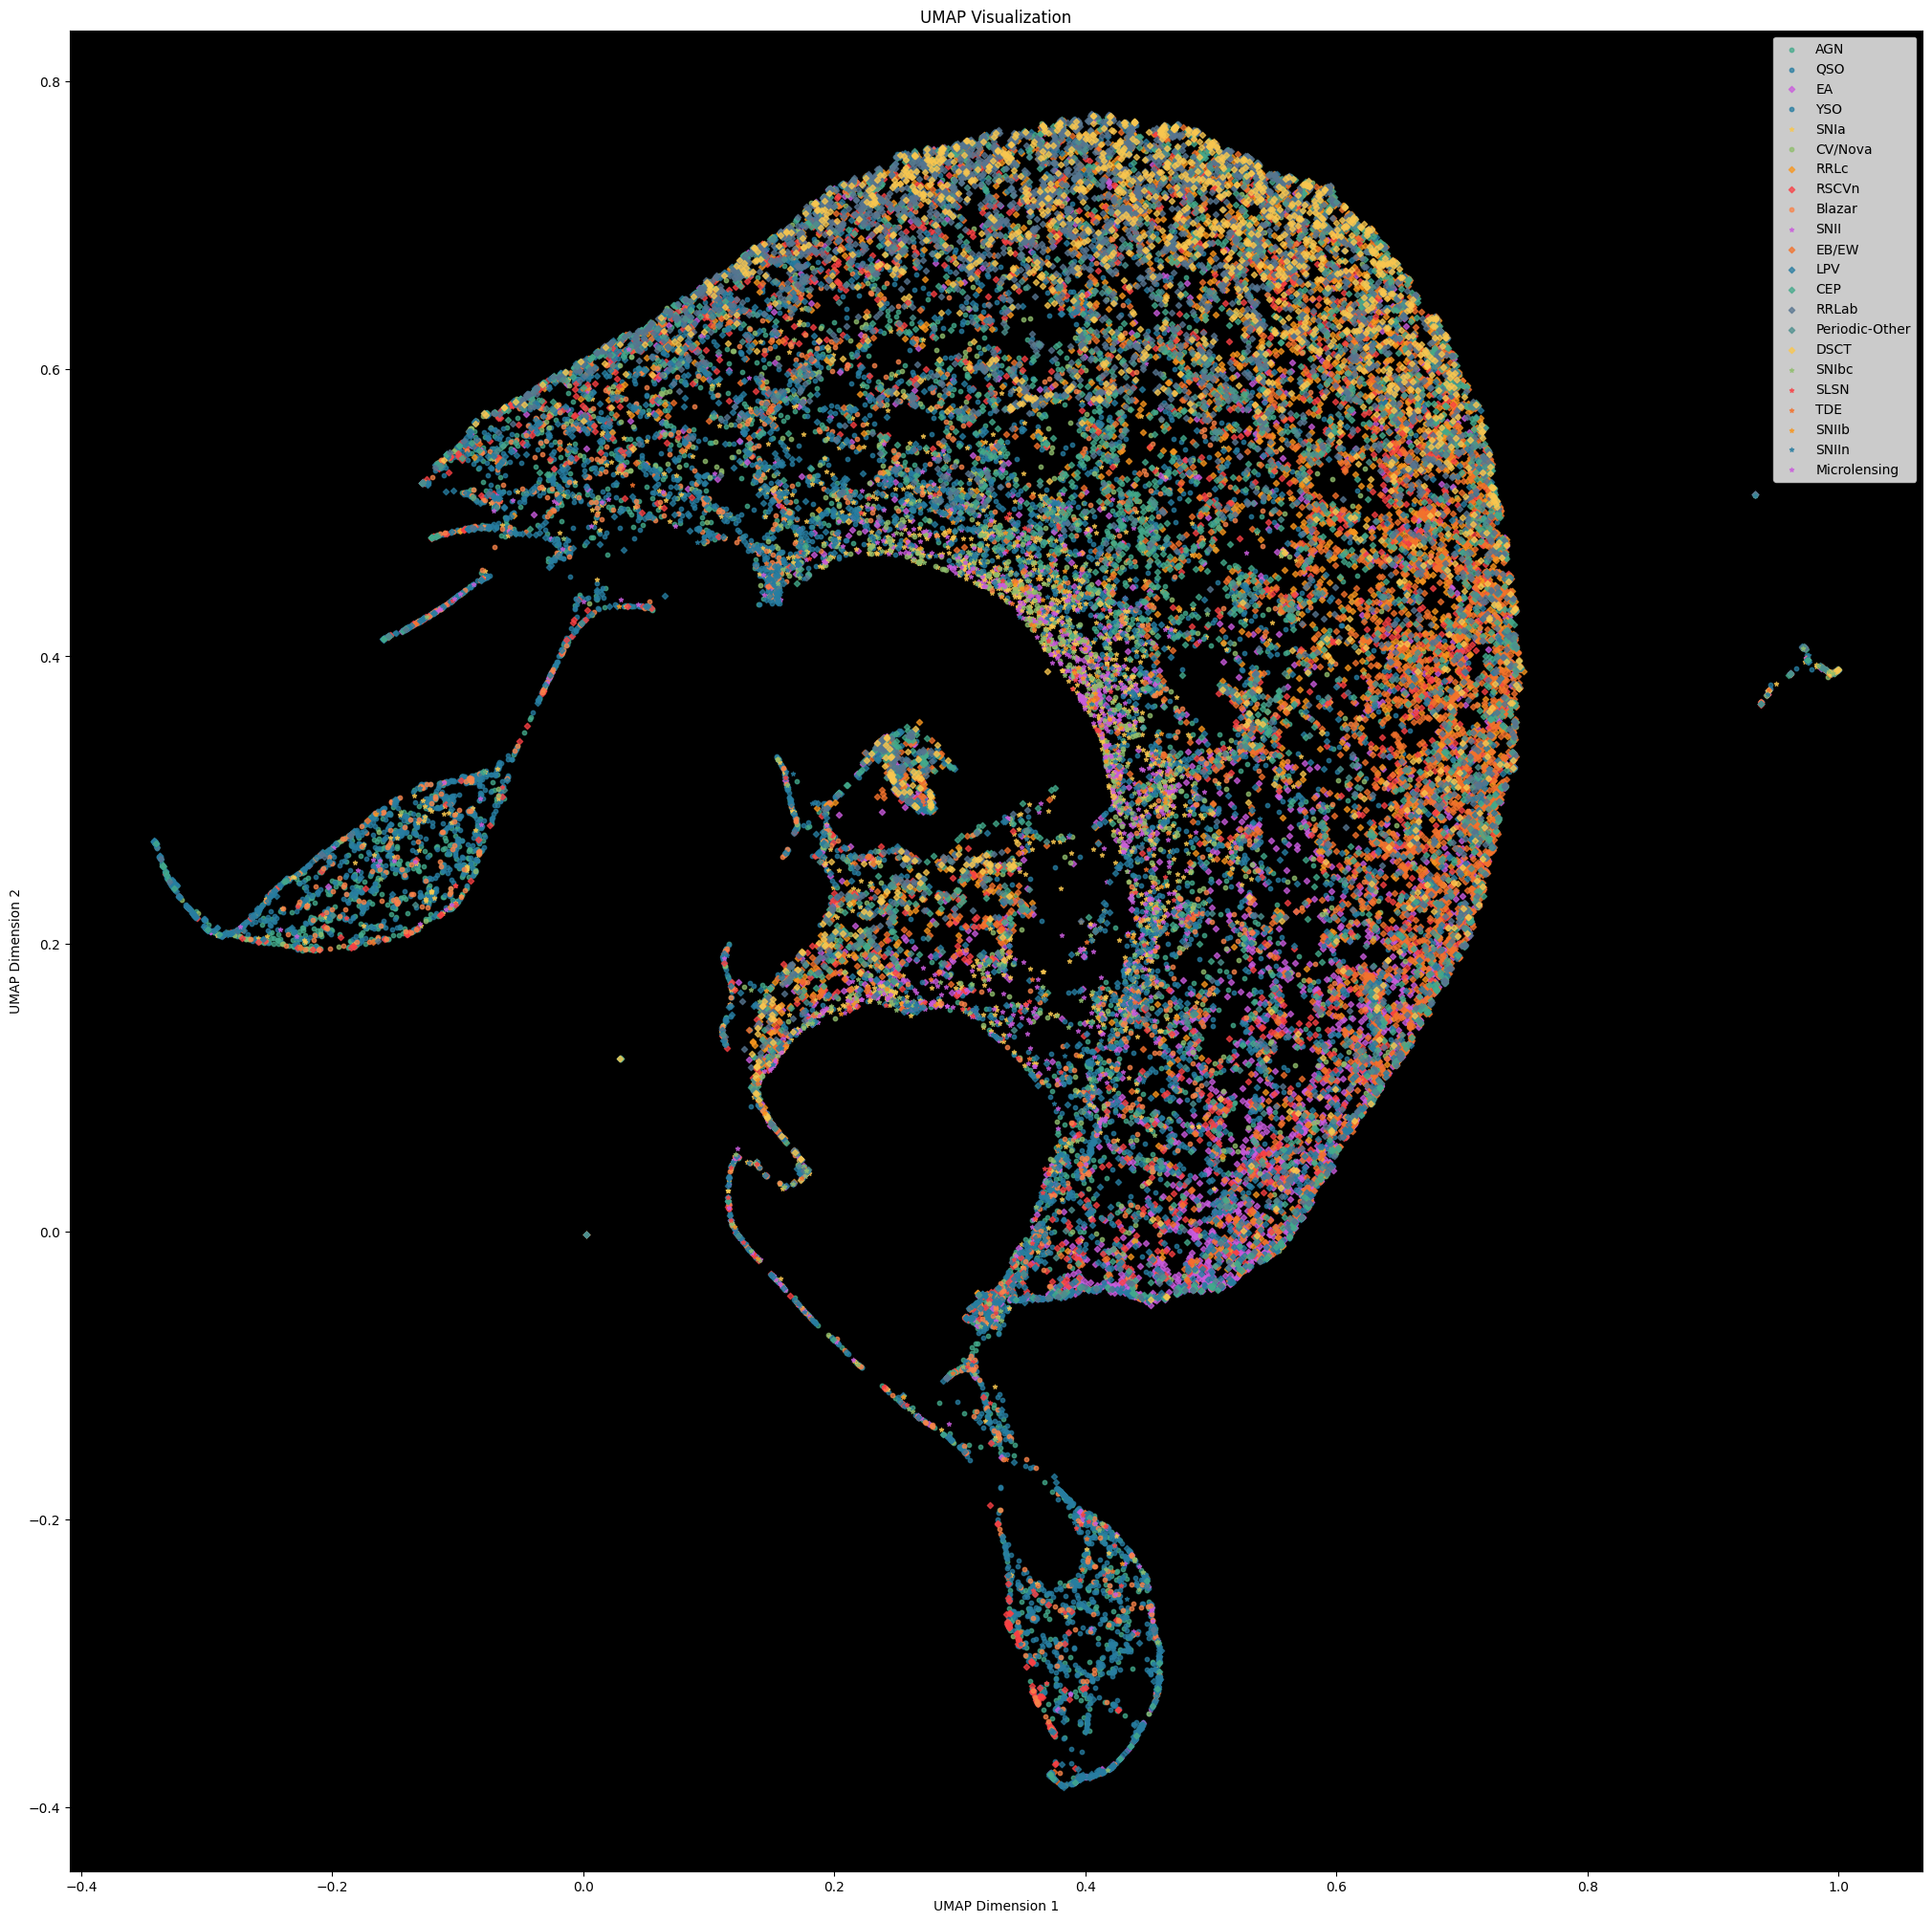

In [87]:

from src.utils.umap_plots import *
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 1, figsize=(25, 25))
plot_umap(axs, umap_result, target, 22,  'UMAP Visualization')

In [88]:
DICT =  {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

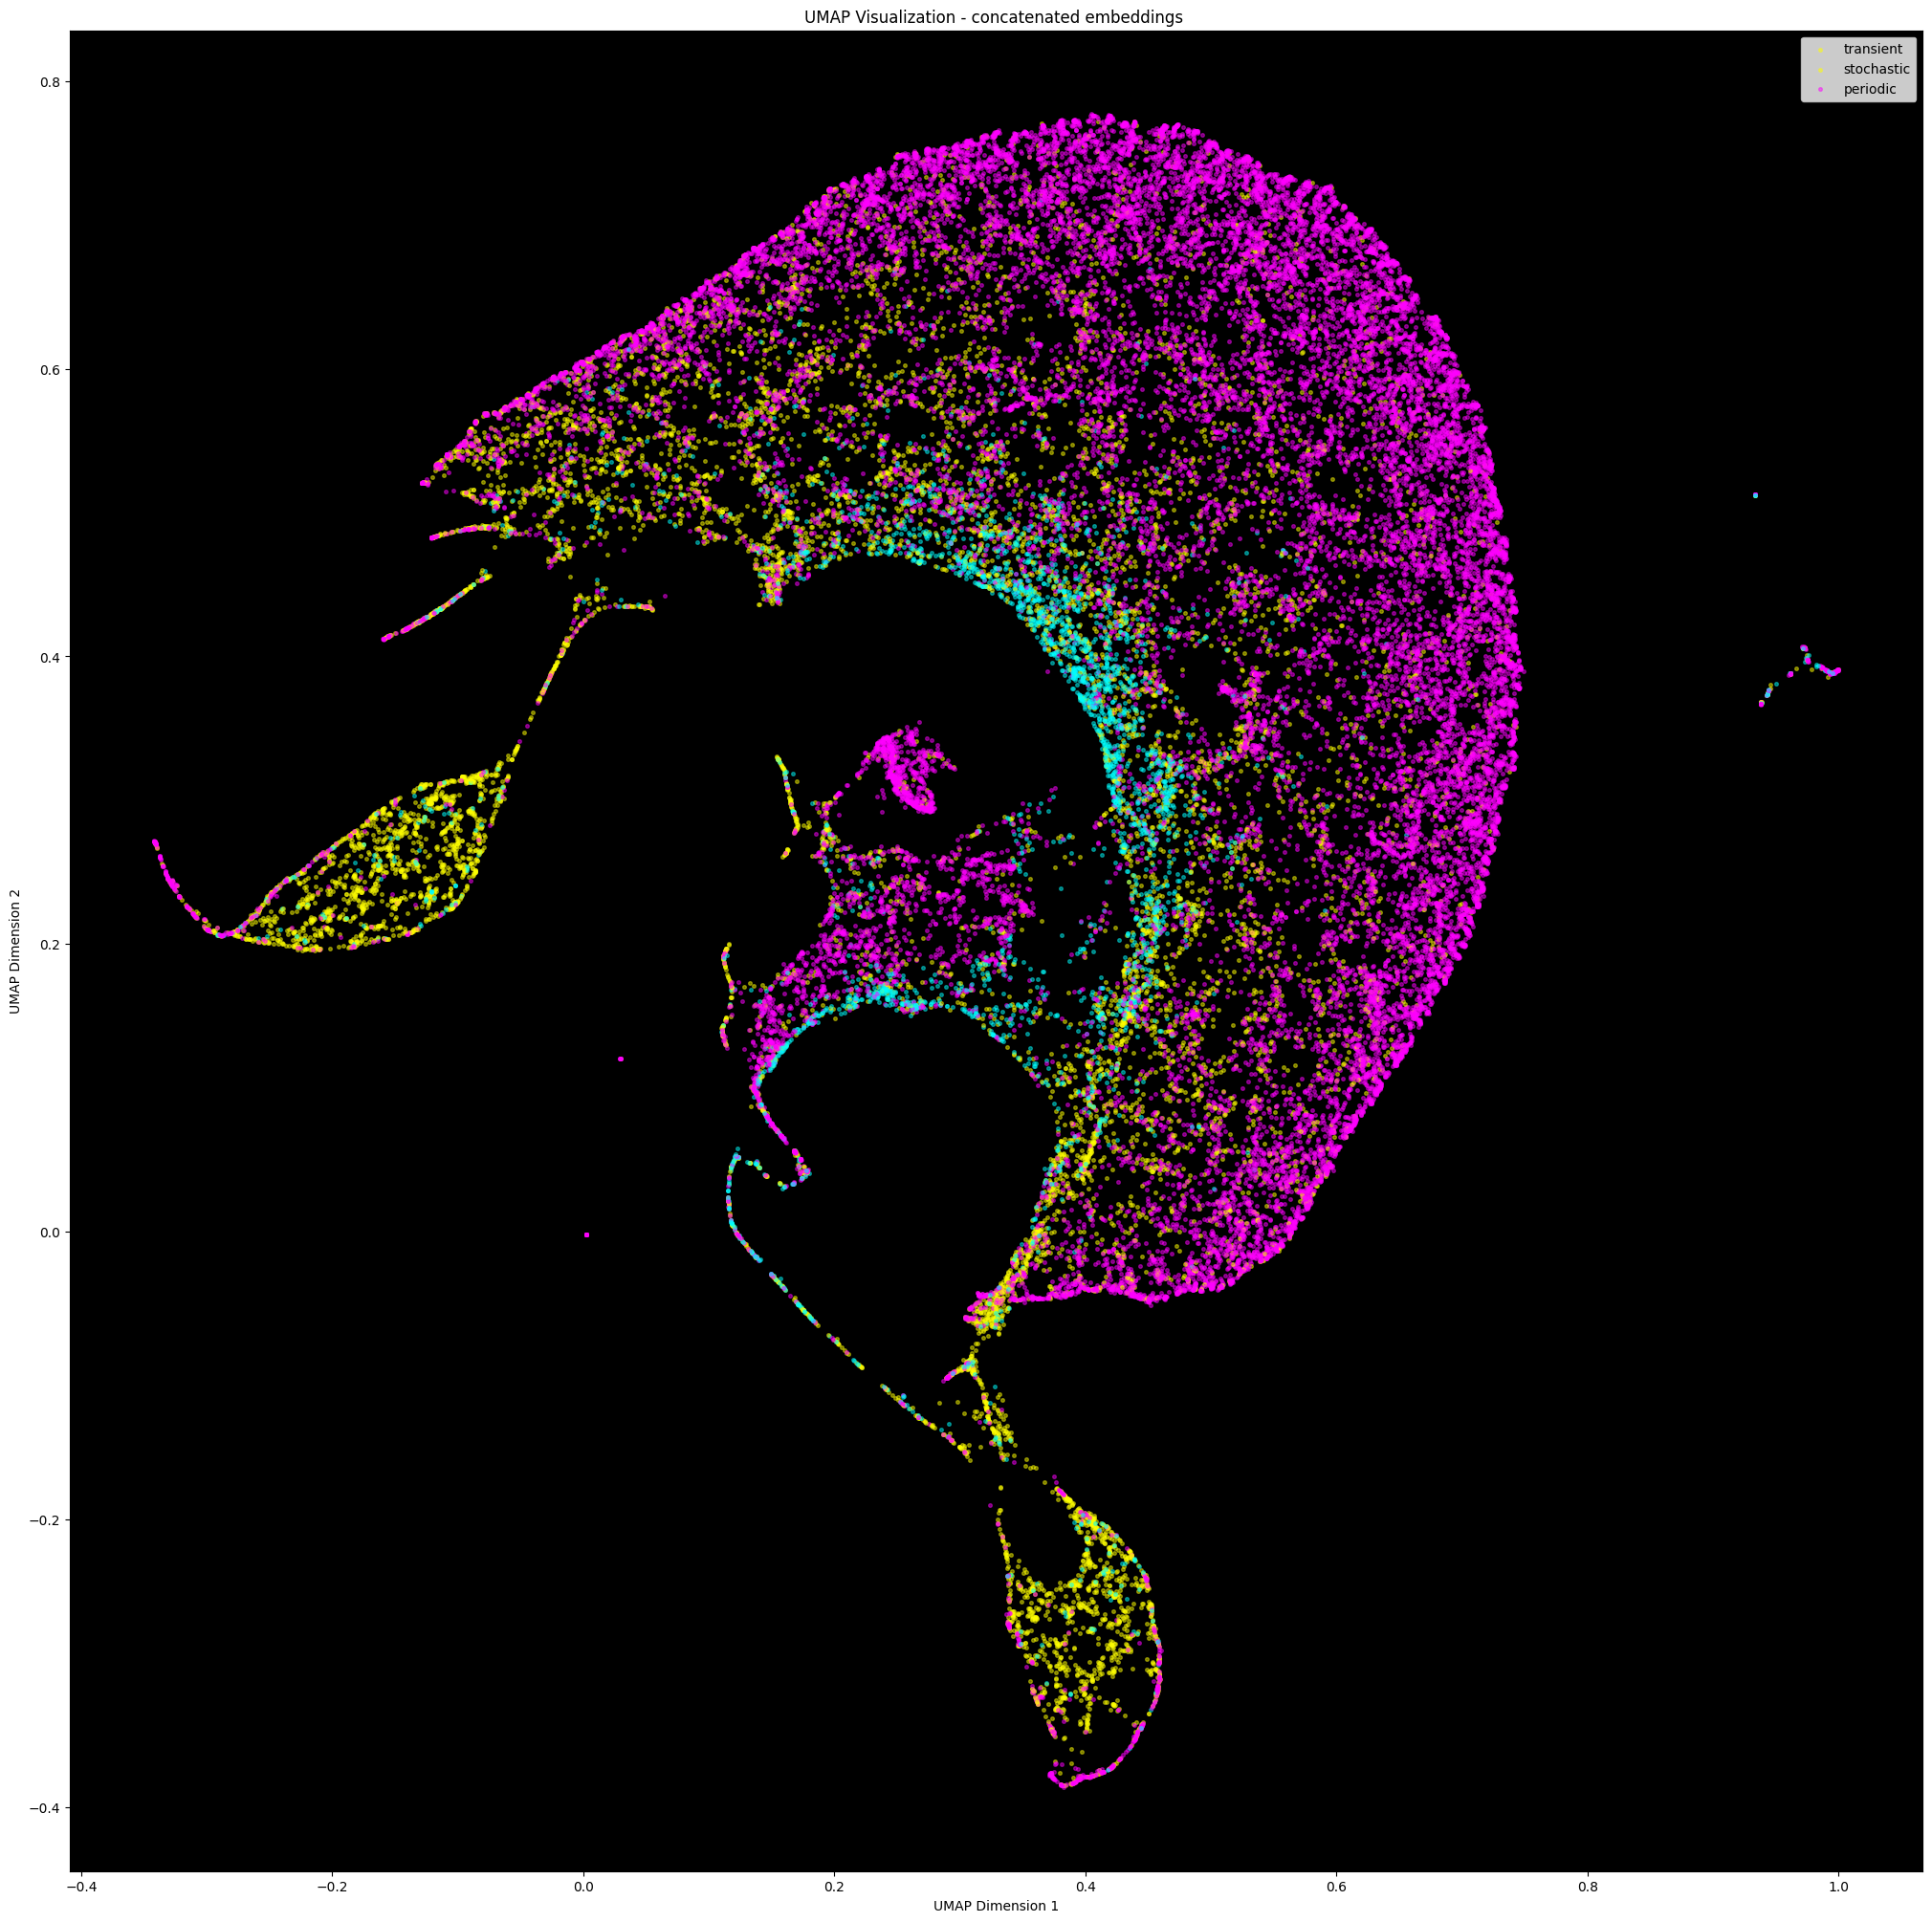

In [89]:
fig, axs = plt.subplots(1, 1, figsize=(25, 25))
big_group_plot_umap(axs, umap_result, target, 22,  'UMAP Visualization - concatenated embeddings ')

In [90]:
from src.data.modules.LitData  import LitData
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 512

pl_datal = LitData(**args['general'])
dataloader = pl_datal.train_dataloader() 
target_train = None
preds_out_train = None

model.eval().to(device = 'cuda:2')  
count = 0


for b1 in tqdm(dataloader):
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    t = b1['labels']
    #print(b1.keys())
    x_emb,t_emb = your_model(**b1)
    x_emb = x_emb[:,0,:]
    t_emb = t_emb[:,0,:]
    preds_out_train = (
        np.concatenate([preds_out_train, x_emb.detach().cpu().numpy()])
        if preds_out_train is not None
        else x_emb.cpu().detach().numpy()
    ) 
    target_train = (
        np.concatenate([target_train, t.cpu().detach().numpy()])
        if target_train is not None
        else t.detach().cpu().numpy()
    )
    if count > 2000:
        break
    count +=1


using set train total of idx : 161611 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type train
NOT USING SAMPLER FOR DATASET train


100%|██████████| 316/316 [00:47<00:00,  6.60it/s]


In [91]:
from src.data.modules.LitData  import LitData
dataloader = pl_datal.val_dataloader() 
target_val = None
preds_out_val = None

model.eval().to(device = 'cuda:2')  
count = 0


for b1 in tqdm(dataloader):
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    t = b1['labels']
    #print(b1.keys())
    x_emb,t_emb = your_model(**b1)
    x_emb = x_emb[:,0,:]
    t_emb = t_emb[:,0,:]
    preds_out_val = (
        np.concatenate([preds_out_val, x_emb.detach().cpu().numpy()])
        if preds_out_val is not None
        else x_emb.cpu().detach().numpy()
    ) 
    target_val = (
        np.concatenate([target_val, t.cpu().detach().numpy()])
        if target_val is not None
        else t.detach().cpu().numpy()
    )
    if count > 2000:
        break
    count +=1

using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


100%|██████████| 80/80 [00:12<00:00,  6.47it/s]


In [92]:
umap_result_train = preds_out_train#umap_model.fit_transform(preds_out_train)
umap_result_val = preds_out_val #umap_model.transform(preds_out_val)

In [93]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10,weights='distance')  # You can change n_neighbors as needed
knn.fit(umap_result_train, target_train)
from sklearn.metrics import accuracy_score, classification_report
y_pred = knn.predict(umap_result_val)
print(classification_report(target_val, y_pred, target_names=list(DICT.keys()),digits=4))

                precision    recall  f1-score   support

           AGN     0.2863    0.2762    0.2812      3288
           QSO     0.4202    0.5163    0.4634      3428
            EA     0.4006    0.4494    0.4236      3500
           YSO     0.2112    0.1838    0.1965      2715
          SNIa     0.2818    0.3691    0.3196      1639
       CV/Nova     0.3170    0.2121    0.2542      1617
          RRLc     0.2932    0.3297    0.3104      3439
         RSCVn     0.2773    0.2454    0.2604      2522
        Blazar     0.2325    0.1562    0.1868      1364
          SNII     0.1755    0.1409    0.1563       802
         EB/EW     0.3222    0.3827    0.3498      3635
           LPV     0.3045    0.2468    0.2726      3319
           CEP     0.3299    0.3393    0.3345      2871
         RRLab     0.3363    0.3998    0.3653      3507
Periodic-Other     0.2222    0.1024    0.1402       742
          DSCT     0.3193    0.2880    0.3029      1604
         SNIbc     0.1389    0.0479    0.0713  

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr